<a href="https://colab.research.google.com/github/IanWilmutF09/Prediksi-Machine-Learning/blob/main/Prediksi-Peningkatan-Suhu-Bumi/Prediksi_Peningkatan_Suhu_Bumi_DES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path to your file
file_path = '/content/drive/My Drive/Skripsi Yosef GH Drive/data_anomali_temperatur_ready.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the file using pandas (for CSV files)
df = pd.read_csv(file_path)

# Display the first few rows of the dataframe
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Year  Month  Anomaly-Monthly  Unc-Monthly  Anomaly-Annual  Unc-Annual  \
0  1850      1           -0.790        0.404             NaN         NaN   
1  1850      2           -0.243        0.524             NaN         NaN   
2  1850      3           -0.394        0.449             NaN         NaN   
3  1850      4           -0.625        0.304             NaN         NaN   
4  1850      5           -0.652        0.249             NaN         NaN   

   Anomaly-Five-Year  Unc-Five-Year  Anomaly-Ten-Year  Unc-Ten-Year  \
0                NaN            NaN               NaN           NaN   
1                NaN            NaN               NaN           NaN   
2                NaN            NaN               NaN           NaN   
3                NaN            NaN               NaN           NaN   
4                NaN            NaN               NaN      

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Baca file CSV
df = pd.read_csv(file_path)

# Menggabungkan kolom 'Year' dan 'Month' menjadi kolom 'time'
df['time'] = df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2)

# Konversi kolom 'time' menjadi datetime
df['time'] = pd.to_datetime(df['time'], format='%Y-%m')

# Memfilter data dari tahun 1950 dan seterusnya
df = df[df['time'].dt.year >= 1950]

# Memilih hanya kolom 'time' dan 'Anomaly-Monthly'
df = df[['time', 'Anomaly-Monthly']]

# Menampilkan DataFrame
print(df)

# List untuk menyimpan nilai rata-rata MSE untuk setiap alpha
mse_results = []

# Iterasi melalui nilai alpha dari 0 hingga 1 dengan interval 0.05
for alpha in np.round(np.arange(0, 1, 0.05), 2):
    # Inisialisasi nilai awal
    s1 = df['Anomaly-Monthly'].iloc[0]
    s2 = s1

    # List untuk menyimpan nilai smoothed pertama dan kedua
    smooth1 = [s1]
    smooth2 = [s2]

    # Single Exponential Smoothing dua kali
    for i in range(1, len(df)):
        value = df['Anomaly-Monthly'].iloc[i]
        s1 = alpha * value + (1 - alpha) * s1
        s2 = alpha * s1 + (1 - alpha) * s2
        smooth1.append(s1)
        smooth2.append(s2)

    # Menghitung nilai smoothed menggunakan formula Brown
    smoothed = [2 * s1 - s2 + alpha / (1 - alpha) * (s1 - s2) for s1, s2 in zip(smooth1, smooth2)]

    # Tambahkan kolom hasil smoothing ke DataFrame
    df['smoothed'] = smoothed

    # Hitung error dan MSE untuk setiap baris
    df['error'] = df['Anomaly-Monthly'] - df['smoothed']
    df['squared_error'] = df['error'] ** 2
    df['mse'] = df['squared_error']

    # Hitung rata-rata MSE
    average_mse = df['mse'].mean()

    # Simpan hasil MSE untuk alpha saat ini
    mse_results.append((alpha, average_mse))

# Cari alpha dengan rata-rata MSE terkecil
best_alpha, min_mse = min(mse_results, key=lambda x: x[1])

# Tampilkan hasil
print("Average MSE for each alpha:")
for alpha, mse in mse_results:
    print(f"Alpha = {alpha}: MSE = {mse}")

print("\nBest alpha based on average MSE:", best_alpha)
print("Minimum average MSE:", min_mse)

           time  Anomaly-Monthly
1200 1950-01-01           -0.235
1201 1950-02-01           -0.342
1202 1950-03-01           -0.117
1203 1950-04-01           -0.199
1204 1950-05-01           -0.065
...         ...              ...
2086 2023-11-01            1.412
2087 2023-12-01            1.439
2088 2024-01-01            1.285
2089 2024-02-01            1.439
2090 2024-03-01            1.330

[891 rows x 2 columns]
Average MSE for each alpha:
Alpha = 0.0: MSE = 0.49671329405162734
Alpha = 0.05: MSE = 0.015531075399458671
Alpha = 0.1: MSE = 0.010791395209147655
Alpha = 0.15: MSE = 0.007853179528827981
Alpha = 0.2: MSE = 0.0058335948121194785
Alpha = 0.25: MSE = 0.0043476566575169785
Alpha = 0.3: MSE = 0.003222327342872991
Alpha = 0.35: MSE = 0.0023728881079577474
Alpha = 0.4: MSE = 0.0017545669459480707
Alpha = 0.45: MSE = 0.0013438442302153423
Alpha = 0.5: MSE = 0.001131013399592005
Alpha = 0.55: MSE = 0.0011170863656421793
Alpha = 0.6: MSE = 0.001312518272258681
Alpha = 0.65: MSE = 0

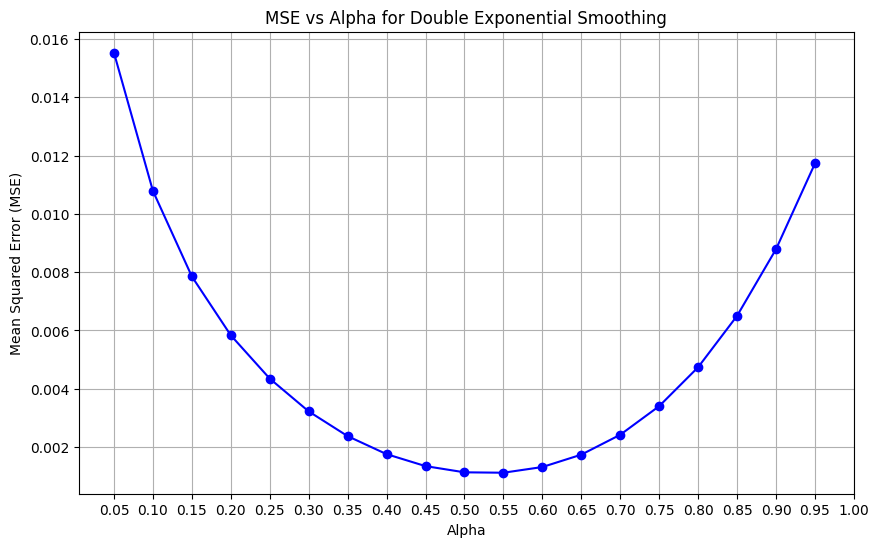

In [ ]:
# Plotting MSE vs Alpha
# Eksklusikan alpha = 0 dari mse_results
filtered_mse_results = [(alpha, mse) for alpha, mse in mse_results if alpha != 0]

# Pisahkan alpha dan mse dari filtered_mse_results
alphas, mses = zip(*filtered_mse_results)

plt.figure(figsize=(10, 6))
plt.plot(alphas, mses, marker='o', linestyle='-', color='b')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs Alpha for Double Exponential Smoothing')
plt.xticks(np.round(np.arange(0.05, 1.05, 0.05), 2))  # Set the tick labels on the x-axis
plt.grid(True)
plt.show()

In [ ]:
df.set_index('time', inplace=True)

# Pastikan index DataFrame adalah tipe datetime dengan format yyyy-mm
df.index = pd.to_datetime(df.index, format='%Y-%m')

# Hitung nilai smoothed untuk plotting per tahun dengan alpha 0.55
alpha = 0.55
s1 = df['Anomaly-Monthly'].iloc[0]
s2 = s1
smooth1 = [s1]
smooth2 = [s2]
for i in range(1, len(df)):
    value = df['Anomaly-Monthly'].iloc[i]
    s1 = alpha * value + (1 - alpha) * s1
    s2 = alpha * s1 + (1 - alpha) * s2
    smooth1.append(s1)
    smooth2.append(s2)

# Menghitung nilai smoothed menggunakan formula Brown
if alpha != 1:
    smoothed = [2 * s1 - s2 + alpha / (1 - alpha) * (s1 - s2) for s1, s2 in zip(smooth1, smooth2)]
else:
    smoothed = [2 * s1 - s2 for s1, s2 in zip(smooth1, smooth2)]  # Hindari pembagian dengan nol

# Tambahkan kolom hasil smoothing ke DataFrame
df['smoothed'] = smoothed

# Menampilkan DataFrame dengan kolom smoothed
print(df)

            Anomaly-Monthly  smoothed     error  squared_error       mse
time                                                                    
1950-01-01           -0.235 -0.235000  0.000000       0.000000  0.000000
1950-02-01           -0.342 -0.352700  0.096300       0.009274  0.009274
1950-03-01           -0.117 -0.125797 -0.192602       0.037096  0.037096
1950-04-01           -0.199 -0.167388  0.053737       0.002888  0.002888
1950-05-01           -0.065 -0.037973 -0.114540       0.013119  0.013119
...                     ...       ...       ...            ...       ...
2023-11-01            1.412  1.450329 -0.003804       0.000014  0.000014
2023-12-01            1.439  1.460979 -0.025012       0.000626  0.000626
2024-01-01            1.285  1.287087  0.136041       0.018507  0.018507
2024-02-01            1.439  1.420643 -0.124548       0.015512  0.015512
2024-03-01            1.330  1.333341  0.084920       0.007211  0.007211

[891 rows x 5 columns]


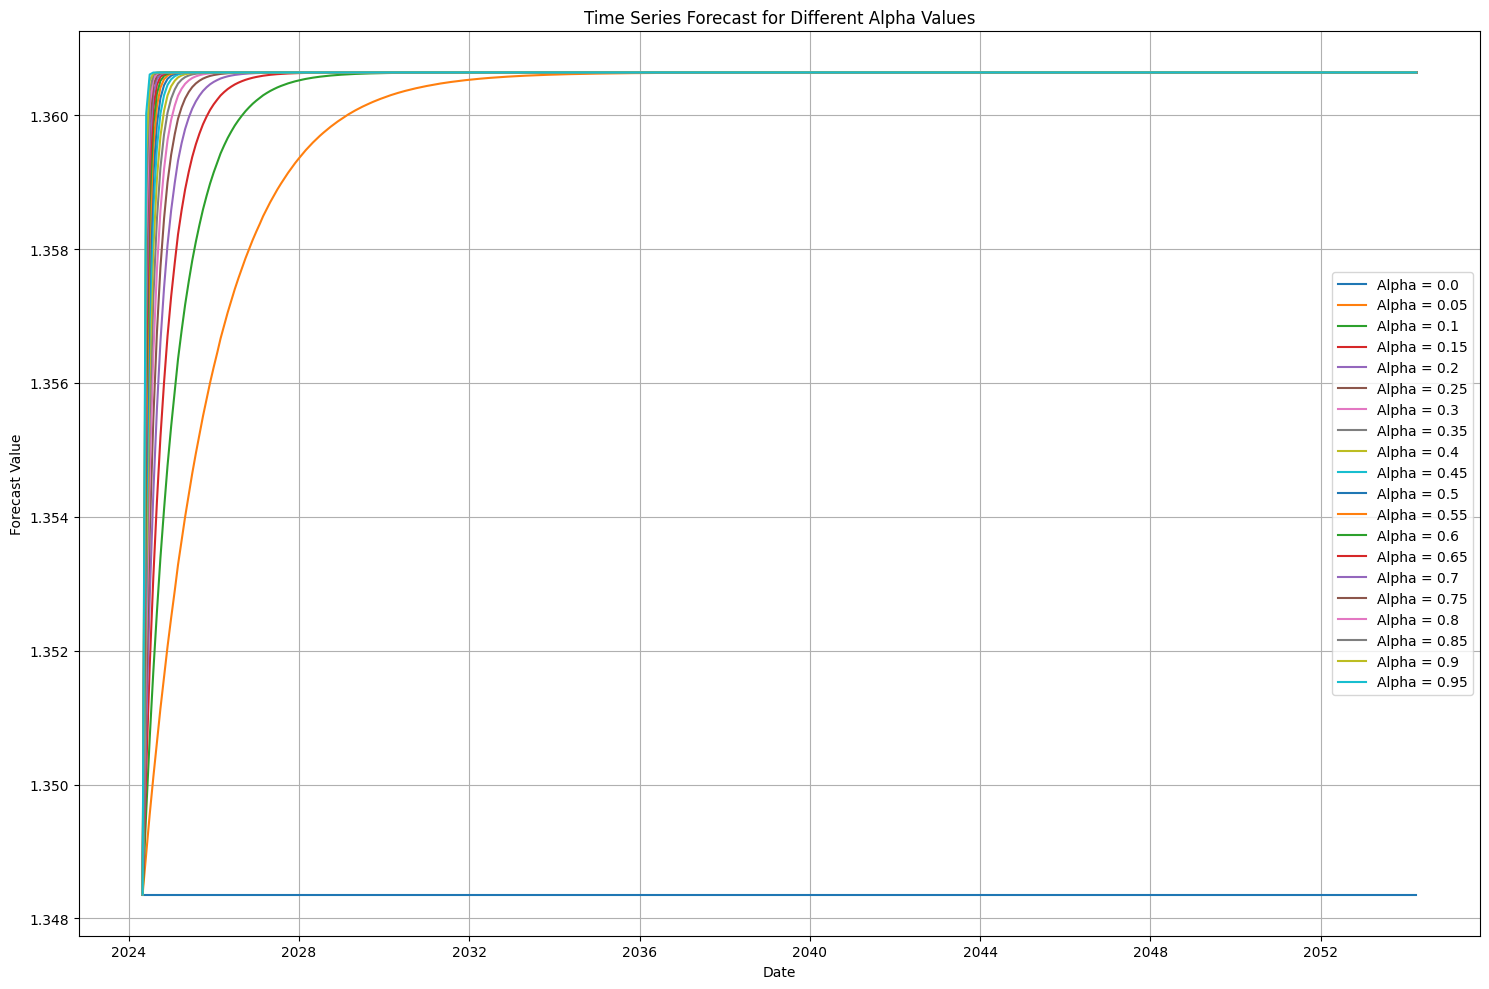

File 'forecast_results.csv' telah disimpan.


In [ ]:
import matplotlib.pyplot as plt

# List untuk menyimpan DataFrame prediksi untuk setiap alpha
forecast_dfs = []

# Iterasi melalui nilai alpha dari 0 hingga 0.95 dengan interval 0.05
for alpha in np.round(np.arange(0, 1, 0.05), 2):
    # Ambil nilai smooth1 dan smooth2 terakhir
    s1 = smooth1[-1]  # Mengakses elemen terakhir dari list smooth1
    s2 = smooth2[-1]  # Mengakses elemen terakhir dari list smooth2

    # Buat list untuk menyimpan nilai prediksi
    forecast_values = []

    # Buat range tanggal untuk 30 tahun ke depan
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date, periods=30*12+1, freq='M')[1:]

    # Lakukan prediksi untuk setiap tanggal di masa depan
    for _ in future_dates:
        new_s1 = alpha * s1 + (1 - alpha) * s1
        new_s2 = alpha * new_s1 + (1 - alpha) * s2
        if alpha != 1:
            forecast = 2 * new_s1 - new_s2 + alpha / (1 - alpha) * (new_s1 - new_s2)
        else:
            forecast = 2 * new_s1 - new_s2  # Hindari pembagian dengan nol
        forecast_values.append(forecast)
        s1, s2 = new_s1, new_s2

    # Buat DataFrame untuk hasil prediksi
    forecast_df = pd.DataFrame(index=future_dates, data={'forecast': forecast_values})
    forecast_dfs.append((alpha, forecast_df))

# Plot hasil prediksi untuk setiap alpha
plt.figure(figsize=(15, 10))
for alpha, forecast_df in forecast_dfs:
    plt.plot(forecast_df.index, forecast_df['forecast'], label=f'Alpha = {alpha}')

plt.title('Time Series Forecast for Different Alpha Values')
plt.xlabel('Date')
plt.ylabel('Forecast Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gabungkan kolom 'forecast' dari setiap DataFrame menjadi satu kolom
combined_df = pd.concat([df for _, df in forecast_dfs], axis=1)
combined_df.columns = [f'Alpha={alpha}' for alpha, _ in forecast_dfs]

# Simpan DataFrame ke dalam file CSV
combined_df.to_csv('forecast_results.csv', index=False)

print("File 'forecast_results.csv' telah disimpan.")